In [1]:
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from scipy.sparse.linalg import svds
from scipy.sparse import vstack
from scipy.sparse import csr_matrix
from scipy.linalg import solve as linalg_solve

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import copy

import movie_recommender.data as movie_data

import torch
import torch.nn as nn

# Model selection

## Data Import

In [2]:
importlib.reload(movie_data)

build_movie_report = movie_data.build_movie_report
build_catalog_eda_frames = movie_data.build_catalog_eda_frames
build_user_eda_frames = movie_data.build_user_eda_frames
build_user_report = movie_data.build_user_report
prepare_movielens_frames = movie_data.prepare_movielens_frames
search_movies = movie_data.search_movies

DATA_DIR = Path("../movies-database")

movies        = pd.read_csv(DATA_DIR / "movies.csv")
ratings       = pd.read_csv(DATA_DIR / "ratings.csv")
tags          = pd.read_csv(DATA_DIR / "tags.csv")
links         = pd.read_csv(DATA_DIR / "links.csv")
genome_scores = pd.read_csv(DATA_DIR / "genome-scores.csv")
genome_tags   = pd.read_csv(DATA_DIR / "genome-tags.csv")

print("movies:       ", movies.shape)
print("ratings:      ", ratings.shape)
print("tags:         ", tags.shape)
print("links:        ", links.shape)
print("genome_scores:", genome_scores.shape)
print("genome_tags:  ", genome_tags.shape)

movies:        (62423, 3)
ratings:       (25000095, 4)
tags:          (1093360, 4)
links:         (62423, 3)
genome_scores: (15584448, 3)
genome_tags:   (1128, 2)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Training spine  (25 M rows, stays lean)
# ─────────────────────────────────────────────────────────────────────────────

# Only merge the lightweight metadata you actually need per-rating.
# Keep genome completely out of this frame.
train = (
    ratings[["userId", "movieId", "rating", "timestamp"]]
    .merge(movies[["movieId", "genres"]], on="movieId", how="left")
)

# Lightweight datetime features for temporal models.
train["year_rated"]  = pd.to_datetime(train["timestamp"], unit="s").dt.year
train["month_rated"] = pd.to_datetime(train["timestamp"], unit="s").dt.month

print(train.shape)
print(train.dtypes)

(25000095, 7)
userId           int64
movieId          int64
rating         float64
timestamp        int64
genres          object
year_rated       int32
month_rated      int32
dtype: object


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Genre one-hot  (62 K × 19 cols)
# ─────────────────────────────────────────────────────────────────────────────
genre_dummies = (
    movies.set_index("movieId")["genres"]
    .str.get_dummies("|")
    .drop(columns=["(no genres listed)"], errors="ignore")
    .add_prefix("genre_")
    .astype("int8")           # saves memory vs int64
)
print(genre_dummies.shape)  # (62_423, 19)

(62423, 19)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Genome: pivot to WIDE once (13 816 × 1 128 ≈ 120 MB in float32)
#           Store as a separate lookup — never join to ratings.
# ─────────────────────────────────────────────────────────────────────────────
tag_id_to_name = genome_tags.set_index("tagId")["tag"]

genome_wide = (
    genome_scores
    .pivot(index="movieId", columns="tagId", values="relevance")
    .astype("float32")
)
genome_wide.columns = [tag_id_to_name.get(t, str(t)) for t in genome_wide.columns]

print(genome_wide.shape)    # (13_816, 1_128)

(13816, 1128)


## Train / Test Split
Per-user split: for each user, sort their own ratings by time and hold out their last ~20% as test.

`df_train` / `df_test` — the outer, per-user temporal split: for each user, the first ~80% of their ratings (by time) go to `df_train`, the last ~20% go to `df_test`, which is the final held-out set, touched exactly once per model.

`df_fit` / `df_val` — `df_train` is split again, per-user, the same way: the first ~90% of each user's training-period ratings go to `df_fit`, the last ~10% go to `df_val`. So, `df_fit` is roughly 72% of the original data, `df_val` ~8%, `df_test` ~20%.

`df_fit` — what every model actually trains on (R_train, R_aug, train_dl all derive from this).

`df_val` — used only for model selection: early-stopping epoch for MF/NCF, best iteration for ALS. Never used to fit any parameters directly.

`df_test` — used exactly once per model, at the end, to report the final RMSE/MAE that goes in the summary table.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Per-user temporal split — last 20% of each user's ratings (by time) held out.
# A global timestamp cutoff strands every "new" user who first rates after the
# cutoff entirely in the test window — that's the cold-start truncation. Splitting
# within each user's own history keeps almost every user evaluable while still
# respecting temporal order *within that user's timeline* (their test ratings
# always come after their train ratings).
# ─────────────────────────────────────────────────────────────────────────────
TEST_FRAC = 0.20

train_sorted = train.sort_values(["userId", "timestamp"], kind="mergesort")

user_rank  = train_sorted.groupby("userId").cumcount()
user_count = train_sorted.groupby("userId")["userId"].transform("size")

# Last ceil (TEST_FRAC * n) ratings per user -> test. Users with too few ratings
# for that to be >=1 (n <= 4 here) land entirely in train.
test_mask = user_rank >= np.ceil(user_count * (1 - TEST_FRAC))

df_train = train_sorted[~test_mask].copy()
df_test  = train_sorted[test_mask].copy()

# Movie cold-start can still occur (rarely): a movie that appears only in
# held-out tails and nowhere in any training history.
known_movies = set(df_train["movieId"])
n_before = len(df_test)
df_test = df_test[df_test["movieId"].isin(known_movies)].copy()

print(f"Train : {len(df_train):>10,}  rows  ({len(df_train)/len(train):.1%})")
print(f"Test  : {len(df_test):>10,}  rows  ({len(df_test)/len(train):.1%})")
print(f"Dropped from test (movie cold-start): {n_before - len(df_test):,}")


Train : 20,062,533  rows  (80.2%)
Test  :  4,925,572  rows  (19.7%)
Dropped from test (movie cold-start): 11,990


## Feature Engineering - Genre Side Features

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Attach genre one-hots to train / test splits
# genre_dummies is indexed by movieId (from cell above), so a simple join works.
# ─────────────────────────────────────────────────────────────────────────────
GENRE_COLS = genre_dummies.columns.tolist()   # e.g. ['genre_Action', ...]
N_GENRES   = len(GENRE_COLS)

df_train = df_train.join(genre_dummies, on="movieId")
df_test  = df_test.join(genre_dummies,  on="movieId")

# Fill any movie that has no genre listing with zeros
df_train[GENRE_COLS] = df_train[GENRE_COLS].fillna(0).astype("float32")
df_test[GENRE_COLS]  = df_test[GENRE_COLS].fillna(0).astype("float32")

print(f"Genre columns added: {N_GENRES}")
print(df_train[GENRE_COLS].head(3))

Genre columns added: 19
    genre_Action  genre_Adventure  genre_Animation  genre_Children  \
36           0.0              1.0              0.0             0.0   
13           0.0              1.0              0.0             0.0   
12           0.0              1.0              0.0             0.0   

    genre_Comedy  genre_Crime  genre_Documentary  genre_Drama  genre_Fantasy  \
36           0.0          0.0                0.0          0.0            1.0   
13           1.0          0.0                0.0          0.0            0.0   
12           1.0          0.0                0.0          0.0            0.0   

    genre_Film-Noir  genre_Horror  genre_IMAX  genre_Musical  genre_Mystery  \
36              0.0           0.0         0.0            0.0            0.0   
13              0.0           0.0         0.0            0.0            0.0   
12              0.0           0.0         0.0            0.0            0.0   

    genre_Romance  genre_Sci-Fi  genre_Thriller  genre_Wa

## Integer Encoding & Sparse Matrix
Both sparse-matrix methods (SVD, MF) and embedding layers (NCF) require contiguous
0-based integer indices. Build the lookup dicts from the **training set only** so
test never leaks new IDs into the vocabulary.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Integer encoding — fit on training set only
# ─────────────────────────────────────────────────────────────────────────────

user_ids  = np.sort(df_train["userId"].unique())
movie_ids = np.sort(df_train["movieId"].unique())

user_to_idx  = {uid: i for i, uid in enumerate(user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}

N_USERS  = len(user_to_idx)
N_MOVIES = len(movie_to_idx)

for df in [df_train, df_test]:
    df["user_idx"]  = df["userId"].map(user_to_idx).astype("int32")
    df["movie_idx"] = df["movieId"].map(movie_to_idx).astype("int32")

print(f"N_USERS={N_USERS:,}   N_MOVIES={N_MOVIES:,}")


N_USERS=162,541   N_MOVIES=51,231


### Validation Split & Rating Normalisation
`df_train` is split once more, per-user, into `df_fit` (what every model actually
trains on) and `df_val` (held out for model selection — early-stopping epochs for
MF/NCF, iteration choice for ALS, and an optional check for SVD/ALS hyperparameters).

`df_test` is now reserved for a single final evaluation per model, computed once at
the very end of each model's section — model selection never sees it.

`user_mean_map` (used for `rating_norm` centring and for denormalising predictions
back to the 1-5 scale) is fit on `df_fit` only, so the same leakage-free mean is
reused for `df_fit`, `df_val`, and `df_test`.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Validation split — carved from df_train, per-user, same logic as the
# train/test split (last VAL_FRAC of each user's TRAINING-period ratings).
# df_val is used for early stopping / iteration selection so that df_test is
# touched exactly once per model, at the end, for the reported metric.
# ─────────────────────────────────────────────────────────────────────────────
VAL_FRAC = 0.10

def per_user_temporal_split(df, frac, group_col="userId", time_col="timestamp"):
    df_sorted = df.sort_values([group_col, time_col], kind="mergesort")
    rank  = df_sorted.groupby(group_col).cumcount()
    count = df_sorted.groupby(group_col)[group_col].transform("size")
    mask  = rank >= np.ceil(count * (1 - frac))
    return df_sorted[~mask].copy(), df_sorted[mask].copy()

df_fit, df_val = per_user_temporal_split(df_train, VAL_FRAC)

print(f"Fit (train) : {len(df_fit):>10,}  rows  ({len(df_fit)/len(df_train):.1%} of df_train)")
print(f"Validation  : {len(df_val):>10,}  rows  ({len(df_val)/len(df_train):.1%} of df_train)")


Fit (train) : 18,128,361  rows  (90.4% of df_train)
Validation  :  1,934,172  rows  (9.6% of df_train)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# user_mean_map from df_fit ONLY (not df_val, not df_test). rating_norm for
# df_fit/df_val/df_test all centre on this one map, so val/test denormalization
# is leakage-free with respect to both the validation rows and the test rows.
# ─────────────────────────────────────────────────────────────────────────────
user_mean_map = df_fit.groupby("user_idx")["rating"].mean()

for df in [df_fit, df_val, df_test]:
    df["rating_norm"] = (df["rating"] - df["user_idx"].map(user_mean_map)).astype("float32")

# ─────────────────────────────────────────────────────────────────────────────
# Sparse user-item matrix (for SVD and ALS) — fit on df_fit, the same rows
# MF/NCF train on via train_dl. rating_norm is user-mean-centred: 0 = unobserved,
# near-0 = average preference.
# ─────────────────────────────────────────────────────────────────────────────
R_train = csr_matrix(
    (df_fit["rating_norm"].values,
     (df_fit["user_idx"].values, df_fit["movie_idx"].values)),
    shape=(N_USERS, N_MOVIES),
    dtype="float32",
)

print(f"Sparse matrix: {R_train.shape}")
print(f"  nnz        : {R_train.nnz:,}")
print(f"  density    : {R_train.nnz / (N_USERS * N_MOVIES):.4%}")


Sparse matrix: (162541, 51231)
  nnz        : 18,128,361
  density    : 0.2177%


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Genre-augmented rating matrix — used by SVD and ALS.
# N_GENRES 'pseudo-user' rows are appended so the factorisation must explain
# both user preferences and genre structure simultaneously, giving SVD and ALS
# the same genre signal that genre_proj provides to MF and NCF.
#
# alpha scales genre 0/1 values to match the magnitude of rating_norm (~1.0).
# Treat it like LAM_ALS — tune with a quick sweep over [0.5, 1.0, 2.0].
# ─────────────────────────────────────────────────────────────────────────────

ALPHA_GENRE = 1.0   # genre signal weight; 0.0 reproduces the ratings-only result

# idx_to_movie and the genre numpy array are also used by the per-user showcase
# — define them here once rather than duplicating in the showcase cell.
idx_to_movie  = {v: k for k, v in movie_to_idx.items()}
all_movie_ids = [idx_to_movie[i] for i in range(N_MOVIES)]
genre_mat     = (genre_dummies
                 .reindex(all_movie_ids)
                 .fillna(0)
                 .values
                 .astype("float32"))          # (N_MOVIES, N_GENRES)

G_pseudo  = csr_matrix((ALPHA_GENRE * genre_mat).T)  # (N_GENRES,  N_MOVIES)
R_aug     = vstack([R_train, G_pseudo], format="csr") # (N_USERS + N_GENRES, N_MOVIES)
N_PSEUDO  = N_GENRES   # number of appended pseudo-user rows

print(f"R_aug : {R_aug.shape}")
print(f"  rating nnz : {R_train.nnz:,}")
print(f"  genre  nnz : {G_pseudo.nnz:,}")
print(f"  total  nnz : {R_aug.nnz:,}")


R_aug : (162560, 51231)
  rating nnz : 18,128,361
  genre  nnz : 91,067
  total  nnz : 18,219,428


## Model 1 - SVD + genre
`scipy.sparse.linalg.svds` decomposes `R_aug` — the rating matrix with genre
pseudo-user rows appended. The resulting `U_aug` is sliced back to `N_USERS`
rows for prediction; the pseudo-user rows act as scaffolding only.

Both hyperparameters — the number of latent factors `k` and the genre weight
`alpha` — are selected on `df_val` via a small grid sweep; `df_test` is touched
once at the end with the chosen factors. The selected alpha is stored as
`ALPHA_SVD` so it doesn't disturb the fixed `ALPHA_GENRE` that ALS reuses.

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SVD + genre (via pseudo-user augmentation)
#
# K_SVD and ALPHA_GENRE are SELECTED on df_val: we sweep a small grid, rebuild
# the genre-augmented matrix for each alpha, factorise, and keep whichever
# (k, alpha) gives the lowest validation RMSE. df_test is touched once at the
# end with the chosen factors — so the val_RMSE reported for SVD is a genuine
# selection metric, directly comparable to MF/NCF/ALS. (ALS keeps the fixed
# upstream ALPHA_GENRE so its augmented matrix R_aug is unchanged; only SVD's
# alpha is tuned here, stored separately as ALPHA_SVD.)
# ─────────────────────────────────────────────────────────────────────────────

K_SVD_GRID   = [20, 50, 100]   # latent factors to try
ALPHA_GRID   = [0.5, 1.0, 2.0] # genre signal weights to try

def build_R_aug(alpha):
    """Genre-augmented matrix for a given alpha (rebuilds the pseudo-user block)."""
    G = csr_matrix((alpha * genre_mat).T)        # (N_GENRES, N_MOVIES)
    return vstack([R_train, G], format="csr")    # (N_USERS + N_GENRES, N_MOVIES)

def fit_svd(R, k):
    """Factorise R and return (U_users, sigma, Vt) with singular values descending."""
    U, s, Vt = svds(R, k=k)
    U, s, Vt = U[:, ::-1], s[::-1], Vt[::-1, :]
    return U[:N_USERS], s, Vt                     # drop pseudo-user rows

def predict_svd(U_svd, sigma, Vt, u_idx, m_idx):
    """Vectorised prediction without materialising the full N x M matrix."""
    return (U_svd[u_idx] * sigma * Vt[:, m_idx].T).sum(axis=1)

def svd_eval(U_svd, sigma, Vt, df):
    preds_norm = predict_svd(U_svd, sigma, Vt, df["user_idx"].values, df["movie_idx"].values)
    preds  = np.clip(preds_norm + df["user_idx"].map(user_mean_map).values, 0.5, 5.0)
    true_r = df["rating"].values
    rmse = float(np.sqrt(np.mean((preds - true_r) ** 2)))
    mae  = float(np.mean(np.abs(preds - true_r)))
    return preds, true_r, rmse, mae

# ── Model selection: sweep (k, alpha) on df_val only ──────────────────────────
best_svd = {"val_rmse": float("inf")}
for alpha in ALPHA_GRID:
    R_a = build_R_aug(alpha)
    for k in K_SVD_GRID:
        U_svd, sigma, Vt = fit_svd(R_a, k)
        _, _, val_rmse, val_mae = svd_eval(U_svd, sigma, Vt, df_val)
        tag = ""
        if val_rmse < best_svd["val_rmse"]:
            best_svd = {"k": k, "alpha": alpha, "val_rmse": val_rmse, "val_mae": val_mae,
                        "U": U_svd, "sigma": sigma, "Vt": Vt}
            tag = " ✓"
        print(f"SVD+genre  k={k:>3}  alpha={alpha:<3}  val_RMSE={val_rmse:.4f}  val_MAE={val_mae:.4f}{tag}")

K_SVD        = best_svd["k"]
ALPHA_SVD    = best_svd["alpha"]
svd_val_rmse = best_svd["val_rmse"]
svd_val_mae  = best_svd["val_mae"]
print(f"\nSelected: k={K_SVD}, alpha={ALPHA_SVD}  "
      f"(best val_RMSE={svd_val_rmse:.4f}, val_MAE={svd_val_mae:.4f})")

# ── Final test metric — computed once, with the selected factors. ─────────────
preds_svd, true_svd, rmse_svd, mae_svd = svd_eval(
    best_svd["U"], best_svd["sigma"], best_svd["Vt"], df_test
)
print(f"SVD+genre (k={K_SVD}, alpha={ALPHA_SVD})  "
      f"test_RMSE={rmse_svd:.4f}  test_MAE={mae_svd:.4f}  (test touched once)")


SVD+genre  k= 20  alpha=0.5  val_RMSE=0.9200  val_MAE=0.6985 ✓
SVD+genre  k= 50  alpha=0.5  val_RMSE=0.9173  val_MAE=0.6963 ✓
SVD+genre  k=100  alpha=0.5  val_RMSE=0.9174  val_MAE=0.6965
SVD+genre  k= 20  alpha=1.0  val_RMSE=0.9200  val_MAE=0.6985
SVD+genre  k= 50  alpha=1.0  val_RMSE=0.9172  val_MAE=0.6962 ✓
SVD+genre  k=100  alpha=1.0  val_RMSE=0.9173  val_MAE=0.6964
SVD+genre  k= 20  alpha=2.0  val_RMSE=0.9203  val_MAE=0.6988
SVD+genre  k= 50  alpha=2.0  val_RMSE=0.9172  val_MAE=0.6962 ✓
SVD+genre  k=100  alpha=2.0  val_RMSE=0.9171  val_MAE=0.6962 ✓

Selected: k=100, alpha=2.0  (best val_RMSE=0.9171, val_MAE=0.6962)
SVD+genre (k=100, alpha=2.0)  test_RMSE=0.9471  test_MAE=0.7192  (test touched once)


## Models 2 & 3 - Matrix Factorisation and Neural CF (PyTorch)
Both architectures are trained sequentially with identical hyperparameters and the same
`train_dl` / `val_dl` / `test_dl` loaders, so their results are directly comparable.
- **MF (GMF)** — embedding dot-product + per-user/movie bias; neural analogue of classic ALS.
- **NCF** — GMF path *and* an MLP path, fused before the output layer (He et al. 2017).

In [13]:
# ── On-GPU batcher ────────────────────────────────────────────────────────────
# The whole dataset fits in memory, so we move every column to the GPU ONCE and
# slice mini-batches with a shuffled index. This skips DataLoader worker
# processes (the source of the "worker exited unexpectedly" crash) and avoids a
# CPU->GPU copy on every batch — both faster and more robust for this workload.
class GPUBatcher:
    def __init__(self, df, genre_cols, device, batch_size, shuffle=True):
        self.u = torch.tensor(df["user_idx"].values,  dtype=torch.long,    device=device)
        self.m = torch.tensor(df["movie_idx"].values, dtype=torch.long,    device=device)
        # rating_norm (user-mean-centred) is the training target — better
        # conditioned than raw rating. train_model adds the per-user mean
        # back during evaluation so metrics stay on the 1-5 star scale.
        self.r = torch.tensor(df["rating_norm"].values, dtype=torch.float32, device=device)
        self.g = torch.tensor(df[genre_cols].values,  dtype=torch.float32, device=device)
        self.n, self.bs, self.shuffle = len(self.r), batch_size, shuffle

    def __len__(self):
        return (self.n + self.bs - 1) // self.bs

    def __iter__(self):
        idx = (torch.randperm(self.n, device=self.u.device) if self.shuffle
               else torch.arange(self.n, device=self.u.device))
        for i in range(0, self.n, self.bs):
            j = idx[i:i + self.bs]
            yield self.u[j], self.m[j], self.r[j], self.g[j]


# ── Model 2: Matrix Factorisation ─────────────────────────────────────────────
class MatrixFactorisation(nn.Module):
    """rating ≈ dot(user_emb, movie_emb + genre_proj) + bias_user + bias_movie"""
    def __init__(self, n_users, n_movies, n_factors=64, n_genres=len(GENRE_COLS)):
        super().__init__()
        self.user_emb   = nn.Embedding(n_users,  n_factors)
        self.movie_emb  = nn.Embedding(n_movies, n_factors)
        self.user_bias  = nn.Embedding(n_users,  1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.genre_proj = nn.Linear(n_genres, n_factors, bias=False)
        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.movie_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
        nn.init.normal_(self.genre_proj.weight, std=0.01)

    def forward(self, u, m, g):
        movie_vec = self.movie_emb(m) + self.genre_proj(g)
        dot  = (self.user_emb(u) * movie_vec).sum(dim=1)
        bias = self.user_bias(u).squeeze(1) + self.movie_bias(m).squeeze(1)
        return dot + bias


# ── Model 3: Neural CF (GMF + MLP) ────────────────────────────────────────────
class NeuralCF(nn.Module):
    """He et al. (2017) extended with genre side-features.
    GMF path: element-wise product of user & (movie + genre_proj).
    MLP path: concat(u_mlp, m_mlp, genre) fed into the MLP tower."""
    def __init__(self, n_users, n_movies,
                 n_factors_gmf=32, n_factors_mlp=32,
                 mlp_hidden=(128, 64, 32), n_genres=len(GENRE_COLS)):
        super().__init__()
        self.u_gmf = nn.Embedding(n_users,  n_factors_gmf)
        self.m_gmf = nn.Embedding(n_movies, n_factors_gmf)
        self.u_mlp = nn.Embedding(n_users,  n_factors_mlp)
        self.m_mlp = nn.Embedding(n_movies, n_factors_mlp)
        self.genre_proj_gmf = nn.Linear(n_genres, n_factors_gmf, bias=False)
        # MLP input: concat(u_mlp, m_mlp, genre_raw) = 2*n_factors_mlp + n_genres
        dims = [2 * n_factors_mlp + n_genres, *mlp_hidden]
        self.mlp = nn.Sequential(*[
            layer
            for in_d, out_d in zip(dims, dims[1:])
            for layer in (nn.Linear(in_d, out_d), nn.ReLU())
        ])
        self.output_layer = nn.Linear(n_factors_gmf + mlp_hidden[-1], 1)
        for emb in (self.u_gmf, self.m_gmf, self.u_mlp, self.m_mlp):
            nn.init.normal_(emb.weight, std=0.01)
        nn.init.normal_(self.genre_proj_gmf.weight, std=0.01)

    def forward(self, u, m, g):
        gmf_out = self.u_gmf(u) * (self.m_gmf(m) + self.genre_proj_gmf(g))
        mlp_out = self.mlp(torch.cat([self.u_mlp(u), self.m_mlp(m), g], dim=1))
        return self.output_layer(torch.cat([gmf_out, mlp_out], dim=1)).squeeze(1)


print("Models defined.")


Models defined.


### Shared Training Config, DataLoaders & Training Loop
Define hyperparameters and build the on-GPU batchers once: `train_dl` (from `df_fit`),
`val_dl` (from `df_val`, used for early stopping / model selection), and `test_dl`
(from `df_test`, evaluated exactly once per model at the end).

`train_model` encapsulates the epoch loop, validation, and best-epoch tracking — driven
entirely by `val_dl` — so neither training cell needs to repeat that logic. `evaluate`
runs the shared one-shot final pass over `test_dl`.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Shared hyperparameters and on-GPU batchers
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_FRAC  = 1   # 1.0 for full run; 0.10 for a fast smoke-test on CPU
BATCH_SIZE   = 4096
LR           = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

df_tr_sample = df_fit.sample(frac=SAMPLE_FRAC, random_state=42)

# No DataLoader workers: the data lives on the GPU, batches are pure index slices.
# This is what makes the training loop's parallel work happen on the GPU.
train_dl = GPUBatcher(df_tr_sample, GENRE_COLS, DEVICE, BATCH_SIZE, shuffle=True)
val_dl   = GPUBatcher(df_val,       GENRE_COLS, DEVICE, BATCH_SIZE, shuffle=False)
test_dl  = GPUBatcher(df_test,      GENRE_COLS, DEVICE, BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_dl):,}   Val batches: {len(val_dl):,}   Test batches: {len(test_dl):,}")

# ─────────────────────────────────────────────────────────────────────────────
# Per-user mean rating, indexed by user_idx — used inside train_model /
# evaluate to denormalize rating_norm predictions/targets back to the 1-5
# star scale.
# ─────────────────────────────────────────────────────────────────────────────
user_means_tensor = torch.tensor(
    user_mean_map.reindex(range(N_USERS)).values.astype("float32"),
    device=DEVICE,
)
print(f"user_means_tensor: {user_means_tensor.shape}")


Device: cpu
Train batches: 4,426   Val batches: 473   Test batches: 1,203
user_means_tensor: torch.Size([162541])


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# evaluate(): one pass over a DataLoader, optionally denormalizing back to the
# 1-5 star scale. Shared by train_model (per-epoch validation) and by each
# model's one-shot final test evaluation.
# ─────────────────────────────────────────────────────────────────────────────

def evaluate(model, dl, device, user_means=None):
    """Run `model` over every batch in `dl` and return (preds, true, rmse, mae).

    If `user_means` is given, both predictions and targets are denormalized
    (rating_norm -> 1-5 star scale) before scoring, and predictions are
    clipped to [0.5, 5.0] — matching SVD/ALS.
    """
    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for u, m, r, g in dl:
            preds = model(u, m, g)
            if user_means is not None:
                means = user_means[u]
                preds = preds + means
                r     = r + means
            preds_all.append(preds.cpu())
            true_all.append(r.cpu())
    preds_t = torch.cat(preds_all).numpy()
    true_t  = torch.cat(true_all).numpy()
    if user_means is not None:
        preds_t = np.clip(preds_t, 0.5, 5.0)
    rmse = float(np.sqrt(np.mean((preds_t - true_t) ** 2)))
    mae  = float(np.mean(np.abs(preds_t - true_t)))
    return preds_t, true_t, rmse, mae


# ─────────────────────────────────────────────────────────────────────────────
# Shared training loop — eliminates copy-paste between MF and NCF.
# Early stopping and best-epoch selection are driven by VALIDATION RMSE
# (df_val via val_dl), never by df_test. After this returns, call
# evaluate(model, test_dl, ...) ONCE to get the number that goes in the
# summary table. `max_epochs` is only a generous safety ceiling — it should
# not be hit in normal operation, and a warning is printed if it is.
# ─────────────────────────────────────────────────────────────────────────────

def train_model(model, train_dl, val_dl, device, lr, weight_decay, label,
                patience=5, user_means=None, max_epochs=100):
    """Train a rating-prediction model until validation RMSE stops improving.

    There is no fixed epoch count — training stops as soon as val RMSE has
    not improved for `patience` consecutive epochs, then the weights from the
    best epoch are restored before returning.

    Parameters
    ----------
    patience : int
        Number of epochs without improvement before stopping (default 5).
    user_means : torch.Tensor, optional
        Per-user mean rating, indexed by user_idx, on `device`. Passed
        straight through to `evaluate` so val_rmse/val_mae are on the raw
        1-5 star scale (comparable to SVD/ALS) even though the model is
        trained on rating_norm.
    max_epochs : int
        Safety ceiling on the number of epochs (default 100). Early stopping
        is expected to trigger well before this; reaching it prints a warning
        and likely means `patience` is too high or the model hasn't converged.

    Returns
    -------
    results : list[dict]  epoch, train_rmse, val_rmse, val_mae per epoch
    """
    optimiser  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion  = nn.MSELoss()
    n_train    = train_dl.n              # correct even when SAMPLE_FRAC < 1

    results       = []
    best_rmse     = float("inf")
    best_weights  = None   # deep-copied state_dict at the best epoch
    epochs_stale  = 0      # consecutive epochs without improvement

    for epoch in range(1, max_epochs + 1):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for u, m, r, g in train_dl:
            optimiser.zero_grad()
            loss = criterion(model(u, m, g), r)
            loss.backward()
            optimiser.step()
            train_loss += loss.item() * len(r)
        train_rmse = (train_loss / n_train) ** 0.5

        # ── Validation ────────────────────────────────────────────────────
        _, _, val_rmse, val_mae = evaluate(model, val_dl, device, user_means)

        results.append({"epoch": epoch, "train_rmse": train_rmse,
                        "val_rmse": val_rmse, "val_mae": val_mae})

        # ── Early-stopping bookkeeping ────────────────────────────────────
        if val_rmse < best_rmse:
            best_rmse    = val_rmse
            best_weights = copy.deepcopy(model.state_dict())
            epochs_stale = 0
            tag = " ✓"
        else:
            epochs_stale += 1
            tag = f" (no improvement {epochs_stale}/{patience})"

        print(f"[{label}] Epoch {epoch}  "
              f"train_RMSE={train_rmse:.4f}  "
              f"val_RMSE={val_rmse:.4f}  "
              f"val_MAE={val_mae:.4f}{tag}")

        if epochs_stale >= patience:
            print(f"[{label}] Early stopping at epoch {epoch} — "
                  f"no improvement for {patience} epochs. "
                  f"Best val RMSE={best_rmse:.4f} "
                  f"(epoch {epoch - patience}).")
            break
    else:
        print(f"[{label}] Reached max_epochs={max_epochs} without "
              f"early stopping — consider raising max_epochs or "
              f"lowering patience. Using best epoch so far "
              f"(val RMSE={best_rmse:.4f}).")

    # Restore the weights that achieved the best validation RMSE.
    model.load_state_dict(best_weights)
    return results


## Model 2 - Matrix Factorisation training
Embedding dot-product + per-user/movie bias; neural analogue of classic ALS.
Results are stored in `results_mf` for the final comparison.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 2: Matrix Factorisation training
# ─────────────────────────────────────────────────────────────────────────────
model_mf = MatrixFactorisation(N_USERS, N_MOVIES, n_factors=64, n_genres=N_GENRES).to(DEVICE)
results_mf = train_model(
    model_mf, train_dl, val_dl, DEVICE, LR, WEIGHT_DECAY, label="MF",
    user_means=user_means_tensor
)

# Final test evaluation — touched once, with the best-by-validation weights.
mf_test_preds, mf_test_true, mf_test_rmse, mf_test_mae = evaluate(
    model_mf, test_dl, DEVICE, user_means=user_means_tensor
)
print(f"[MF] FINAL test_RMSE={mf_test_rmse:.4f}  test_MAE={mf_test_mae:.4f}  (test touched once)")


[MF] Epoch 1  train_RMSE=0.8466  val_RMSE=0.8347  val_MAE=0.6288 ✓
[MF] Epoch 2  train_RMSE=0.8085  val_RMSE=0.8239  val_MAE=0.6212 ✓
[MF] Epoch 3  train_RMSE=0.7969  val_RMSE=0.8201  val_MAE=0.6181 ✓
[MF] Epoch 4  train_RMSE=0.7902  val_RMSE=0.8184  val_MAE=0.6167 ✓
[MF] Epoch 5  train_RMSE=0.7859  val_RMSE=0.8175  val_MAE=0.6160 ✓
[MF] Epoch 6  train_RMSE=0.7832  val_RMSE=0.8170  val_MAE=0.6157 ✓
[MF] Epoch 7  train_RMSE=0.7813  val_RMSE=0.8169  val_MAE=0.6155 ✓
[MF] Epoch 8  train_RMSE=0.7800  val_RMSE=0.8164  val_MAE=0.6152 ✓
[MF] Epoch 9  train_RMSE=0.7790  val_RMSE=0.8164  val_MAE=0.6152 (no improvement 1/5)
[MF] Epoch 10  train_RMSE=0.7783  val_RMSE=0.8163  val_MAE=0.6151 ✓
[MF] Epoch 11  train_RMSE=0.7777  val_RMSE=0.8161  val_MAE=0.6149 ✓
[MF] Epoch 12  train_RMSE=0.7773  val_RMSE=0.8163  val_MAE=0.6150 (no improvement 1/5)
[MF] Epoch 13  train_RMSE=0.7768  val_RMSE=0.8161  val_MAE=0.6149 ✓
[MF] Epoch 14  train_RMSE=0.7765  val_RMSE=0.8160  val_MAE=0.6149 ✓
[MF] Epoch 15  trai

## Model 3 - Neural CF (GMF + MLP) training
Two separate embedding spaces — one for element-wise product (GMF path), one fed into an MLP —
fused before the output layer (He et al. 2017).
Results are stored in `results_ncf` for the final comparison.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 3: Neural CF training
# ─────────────────────────────────────────────────────────────────────────────
model_ncf = NeuralCF(N_USERS, N_MOVIES, n_factors_gmf=32, n_factors_mlp=32,
                     n_genres=N_GENRES).to(DEVICE)
results_ncf = train_model(
    model_ncf, train_dl, val_dl, DEVICE, LR, WEIGHT_DECAY, label="NCF",
    user_means=user_means_tensor
)

# Final test evaluation — touched once, with the best-by-validation weights.
ncf_test_preds, ncf_test_true, ncf_test_rmse, ncf_test_mae = evaluate(
    model_ncf, test_dl, DEVICE, user_means=user_means_tensor
)
print(f"[NCF] FINAL test_RMSE={ncf_test_rmse:.4f}  test_MAE={ncf_test_mae:.4f}  (test touched once)")


[NCF] Epoch 1  train_RMSE=0.8299  val_RMSE=0.8174  val_MAE=0.6169 ✓
[NCF] Epoch 2  train_RMSE=0.7853  val_RMSE=0.7983  val_MAE=0.6018 ✓
[NCF] Epoch 3  train_RMSE=0.7595  val_RMSE=0.7905  val_MAE=0.5944 ✓
[NCF] Epoch 4  train_RMSE=0.7440  val_RMSE=0.7863  val_MAE=0.5913 ✓
[NCF] Epoch 5  train_RMSE=0.7353  val_RMSE=0.7854  val_MAE=0.5902 ✓
[NCF] Epoch 6  train_RMSE=0.7303  val_RMSE=0.7840  val_MAE=0.5894 ✓
[NCF] Epoch 7  train_RMSE=0.7274  val_RMSE=0.7836  val_MAE=0.5898 ✓
[NCF] Epoch 8  train_RMSE=0.7252  val_RMSE=0.7842  val_MAE=0.5890 (no improvement 1/5)
[NCF] Epoch 9  train_RMSE=0.7237  val_RMSE=0.7838  val_MAE=0.5898 (no improvement 2/5)
[NCF] Epoch 10  train_RMSE=0.7224  val_RMSE=0.7841  val_MAE=0.5897 (no improvement 3/5)
[NCF] Epoch 11  train_RMSE=0.7214  val_RMSE=0.7848  val_MAE=0.5895 (no improvement 4/5)
[NCF] Epoch 12  train_RMSE=0.7206  val_RMSE=0.7843  val_MAE=0.5899 (no improvement 5/5)
[NCF] Early stopping at epoch 12 — no improvement for 5 epochs. Best val RMSE=0.7836 (

## Model 4 - Alternating Least Squares (ALS) + genre
Same closed-form ALS as before, but operating on `R_aug`. The user-factor matrix
`U_als` is extended to `N_USERS + N_PSEUDO` rows; the extra rows correspond to
genre pseudo-users and are solved exactly like real users. Predictions still
index only `u_idx < N_USERS`, so the evaluation is unchanged.

Iteration selection is driven by **validation RMSE** (`df_val`): at each iteration
the factors are scored against `df_val`, and the best-by-validation `U_als`/`V_als`
are kept. `df_test` is evaluated once at the very end with those factors — see the
Evaluation Summary section.

ALS operates on the **full** augmented matrix — no `SAMPLE_FRAC` — which
is the correct usage for a closed-form solver. Expected runtime: ~28 s/iteration
on a modern CPU (~5 min for 10 iterations). Reduce `K_ALS` or `N_ITER` for a
quicker smoke-test. For production scale use an optimised library such as
`implicit` (CPU/GPU C++) or Spark MLlib ALS.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# ALS + genre (via pseudo-user augmentation)
# For each user/pseudo-user u: (V_Sᵤ.T V_Sᵤ + λI) U_u = V_Sᵤ.T r_Sᵤ
# For each movie m:            (U_Sₘ.T U_Sₘ + λI) V_m = U_Sₘ.T r_Sₘ
#
# Iteration selection is driven by VALIDATION RMSE (df_val); df_test is
# evaluated once at the end, using the best-by-validation factors.
# ─────────────────────────────────────────────────────────────────────────────
K_ALS   = 50    # latent factors — matches K_SVD for a direct comparison
LAM_ALS = 1     # L2 regularisation strength
N_ITER  = 10    # alternating iterations (ALS converges fast)

N_TOTAL   = N_USERS + N_PSEUDO         # real users + genre pseudo-users
R_als_csr = R_aug                      # (N_TOTAL   × N_MOVIES) — row access per user
R_als_csc = R_aug.T.tocsr()            # (N_MOVIES  × N_TOTAL ) — row access per movie

rng   = np.random.default_rng(42)
U_als = rng.standard_normal((N_TOTAL,  K_ALS)).astype("float32") * 0.01
V_als = rng.standard_normal((N_MOVIES, K_ALS)).astype("float32") * 0.01
reg   = LAM_ALS * np.eye(K_ALS, dtype="float32")

def als_eval(U, V, df):
    """Predict and score ALS factors against `df` (rating_norm + user_mean_map)."""
    u_idx, m_idx = df["user_idx"].values, df["movie_idx"].values
    preds_norm = (U[u_idx] * V[m_idx]).sum(axis=1)
    preds  = np.clip(preds_norm + df["user_idx"].map(user_mean_map).values, 0.5, 5.0)
    true_r = df["rating"].values
    rmse = float(np.sqrt(np.mean((preds - true_r) ** 2)))
    mae  = float(np.mean(np.abs(preds - true_r)))
    return preds, true_r, rmse, mae

results_als   = []
best_val_rmse = float("inf")
best_U_als = best_V_als = best_iter_als = None

for it in range(1, N_ITER + 1):

    # ── User + pseudo-user update ─────────────────────────────────────────
    # B_U[u] = Σ_{i∈Sᵤ} r_ui · V_i  — right-hand sides for all rows at once
    B_U = R_als_csr @ V_als                         # (N_TOTAL, K)  sparse×dense
    for u in range(N_TOTAL):                        # includes N_PSEUDO genre rows
        lo, hi = R_als_csr.indptr[u], R_als_csr.indptr[u + 1]
        if lo == hi:
            continue
        V_Su     = V_als[R_als_csr.indices[lo:hi]]  # (n_i, K)
        A_u      = V_Su.T @ V_Su + reg               # (K, K)  — pos-def
        U_als[u] = linalg_solve(A_u, B_U[u], assume_a="pos")

    # ── Movie update — unchanged ──────────────────────────────────────────
    # B_V[m] = Σ_{u∈Sₘ} r_um · U_u  — right-hand sides for all movies at once
    B_V = R_als_csc @ U_als                         # (N_MOVIES, K)  sparse×dense
    for m in range(N_MOVIES):
        lo, hi = R_als_csc.indptr[m], R_als_csc.indptr[m + 1]
        if lo == hi:
            continue
        U_Sm     = U_als[R_als_csc.indices[lo:hi]]  # (n_j, K)
        A_m      = U_Sm.T @ U_Sm + reg
        V_als[m] = linalg_solve(A_m, B_V[m], assume_a="pos")

    # ── Selection metric: VALIDATION, not test ─────────────────────────────
    _, _, val_rmse, val_mae = als_eval(U_als, V_als, df_val)
    results_als.append({"iter": it, "val_rmse": val_rmse, "val_mae": val_mae})

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_U_als, best_V_als, best_iter_als = U_als.copy(), V_als.copy(), it
        tag = " ✓"
    else:
        tag = ""

    print(f"[ALS+genre] Iter {it:>2}/{N_ITER}  "
          f"val_RMSE={val_rmse:.4f}  val_MAE={val_mae:.4f}{tag}")

# ── Final test evaluation, once, with the best-by-validation factors ───────
als_test_preds, als_test_true, als_test_rmse, als_test_mae = als_eval(best_U_als, best_V_als, df_test)
print(f"\n[ALS+genre] Best iter={best_iter_als} (val_RMSE={best_val_rmse:.4f})  "
      f"FINAL test_RMSE={als_test_rmse:.4f}  test_MAE={als_test_mae:.4f}  (test touched once)")


[ALS+genre] Iter  1/10  val_RMSE=0.9484  val_MAE=0.7185 ✓
[ALS+genre] Iter  2/10  val_RMSE=0.9235  val_MAE=0.6884 ✓
[ALS+genre] Iter  3/10  val_RMSE=0.9096  val_MAE=0.6769 ✓
[ALS+genre] Iter  4/10  val_RMSE=0.9035  val_MAE=0.6716 ✓
[ALS+genre] Iter  5/10  val_RMSE=0.9008  val_MAE=0.6691 ✓
[ALS+genre] Iter  6/10  val_RMSE=0.8997  val_MAE=0.6678 ✓
[ALS+genre] Iter  7/10  val_RMSE=0.8994  val_MAE=0.6671 ✓
[ALS+genre] Iter  8/10  val_RMSE=0.8994  val_MAE=0.6668
[ALS+genre] Iter  9/10  val_RMSE=0.8996  val_MAE=0.6667
[ALS+genre] Iter 10/10  val_RMSE=0.9000  val_MAE=0.6666

[ALS+genre] Best iter=7 (val_RMSE=0.8994)  FINAL test_RMSE=0.9319  test_MAE=0.6919  (test touched once)


## Evaluation Summary
Each model contributes two numbers: `val_RMSE`/`val_MAE` — the metric used to select
its hyperparameters and its epoch/iteration (k/alpha for SVD, epoch for MF/NCF,
iteration for ALS) — and `test_RMSE`/`test_MAE`, computed exactly once on the
held-out test set. `df_test` was never used for any selection decision, so the test
column is an unbiased estimate of generalisation.

The global-mean baseline (fit on `df_fit`) tells you the minimum bar any model must clear.

In [19]:
mf_best  = min(results_mf,  key=lambda r: r["val_rmse"])
ncf_best = min(results_ncf, key=lambda r: r["val_rmse"])
als_best_val_mae = next(r["val_mae"] for r in results_als if r["iter"] == best_iter_als)

summary = pd.DataFrame([
    {"model": f"SVD (k={K_SVD}, alpha={ALPHA_SVD})",
     "val_RMSE": svd_val_rmse,         "val_MAE": svd_val_mae,
     "test_RMSE": rmse_svd,            "test_MAE": mae_svd},
    {"model": f"ALS (k={K_ALS}, iter {best_iter_als})",
     "val_RMSE": best_val_rmse,        "val_MAE": als_best_val_mae,
     "test_RMSE": als_test_rmse,       "test_MAE": als_test_mae},
    {"model": f"MatrixFactorisation (epoch {mf_best['epoch']})",
     "val_RMSE": mf_best["val_rmse"],  "val_MAE": mf_best["val_mae"],
     "test_RMSE": mf_test_rmse,        "test_MAE": mf_test_mae},
    {"model": f"NeuralCF (epoch {ncf_best['epoch']})",
     "val_RMSE": ncf_best["val_rmse"], "val_MAE": ncf_best["val_mae"],
     "test_RMSE": ncf_test_rmse,       "test_MAE": ncf_test_mae},
])
summary = summary.sort_values("test_RMSE").reset_index(drop=True)
fmt_cols = ["val_RMSE", "val_MAE", "test_RMSE", "test_MAE"]
display(summary.style.format({c: "{:.4f}" for c in fmt_cols}))

global_mean = df_fit["rating"].mean()
rmse_naive  = np.sqrt(np.mean((global_mean - df_test["rating"].values) ** 2))
print(f"\nGlobal-mean baseline RMSE = {rmse_naive:.4f}  "
      f"(every trained model must beat this)")


,model,val_RMSE,val_MAE,test_RMSE,test_MAE
0,NeuralCF (epoch 7),0.7836,0.5898,0.8121,0.6104
1,MatrixFactorisation (epoch 24),0.8153,0.6143,0.8419,0.6333
2,"ALS (k=50, iter 7)",0.8994,0.6671,0.9319,0.6919
3,"SVD (k=100, alpha=2.0)",0.9171,0.6962,0.9471,0.7192



Global-mean baseline RMSE = 1.0600  (every trained model must beat this)


## Confusion Matrix

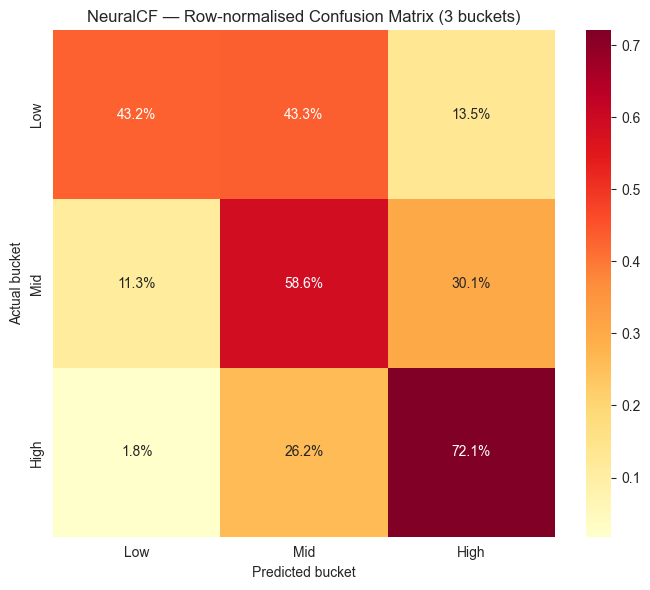

In [20]:
def bucket(ratings):
    # Right-OPEN intervals so each boundary lands in the bucket its label names:
    #   Low  = [0.5, 2.5)   Mid = [2.5, 3.5)   High = [3.5, 5.0]
    # (a 2.5 is "Mid", a 3.5 is "High" — matching the printed labels).
    return pd.cut(
        ratings,
        bins=[0.5, 2.5, 3.5, 5.01],
        labels=["Low (<2.5)", "Mid (2.5-3.5)", "High (3.5-5.0)"],
        right=False,
        include_lowest=True,
    )

# Clip both arrays into the valid rating range before bucketing so no value
# can fall outside the bins and become NaN (which would break confusion_matrix).
true_buckets = bucket(np.clip(ncf_test_true,  0.5, 5.0))
pred_buckets = bucket(np.clip(ncf_test_preds, 0.5, 5.0))

cm3 = confusion_matrix(true_buckets, pred_buckets,
                        labels=["Low (<2.5)", "Mid (2.5-3.5)", "High (3.5-5.0)"])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm3 / cm3.sum(axis=1, keepdims=True),  # row-normalise → recall per class
    annot=True, fmt=".1%", cmap="YlOrRd",
    xticklabels=["Low", "Mid", "High"],
    yticklabels=["Low", "Mid", "High"], ax=ax
)
ax.set_xlabel("Predicted bucket")
ax.set_ylabel("Actual bucket")
ax.set_title("NeuralCF — Row-normalised Confusion Matrix (3 buckets)")
plt.tight_layout()
plt.show()

## Per-User Showcase — Liked Movies vs. NCF Recommendations
For a handful of test users we display:
- **Liked in training** — up to 5 movies rated ≥ 4.0 during training (what the model *learned* from).
- **Rated in test** — actual high-rated movies the user gave ≥ 4.0 in the held-out period.
- **NCF Top-10** — movies the model ranks highest among everything the user has *never* rated.

The model scores every unrated movie for each sampled user using the trained `model_ncf` (genre-aware).

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Per-user showcase: liked movies in training vs. held-out test vs. NCF top-N
# ─────────────────────────────────────────────────────────────────────────────
import textwrap

N_SAMPLE_USERS  = 5
TOP_N           = 5
MIN_LIKED       = 5   # skip users who barely rated anything in training
MIN_TEST_LIKED  = 1   # require at least one liked (>=4.0) rating in the held-out period

# ── Lookup helpers (idx_to_movie / all_movie_ids / genre_mat defined in R_aug cell) ──
movie_title   = movies.set_index("movieId")["title"]
movie_genres  = movies.set_index("movieId")["genres"]

genre_tensor_all = torch.tensor(genre_mat, dtype=torch.float32).to(DEVICE)

# ── Pick sample users ─────────────────────────────────────────────────────────
liked_train = df_train[df_train["rating"] >= 4.0]
liked_test  = df_test[df_test["rating"] >= 4.0]

train_counts = liked_train.groupby("user_idx").size()
test_counts  = liked_test.groupby("user_idx").size()

# Eligible: enough liked training history AND at least one liked test rating,
# so "RATED IN TEST" is never empty for the sampled users.
eligible_users = (
    train_counts[train_counts >= MIN_LIKED].index
    .intersection(test_counts[test_counts >= MIN_TEST_LIKED].index)
    .tolist()
)

rng_sc           = np.random.default_rng(42)
sample_user_idxs = rng_sc.choice(eligible_users, size=N_SAMPLE_USERS, replace=False)

model_ncf.eval()

def fmt_movie(mid, extra=""):
    title  = movie_title.get(mid, "Unknown")
    genres = movie_genres.get(mid, "")
    genres_short = ", ".join(genres.split("|")[:3])  # first 3 genres max
    return f"{title}  [{genres_short}]{extra}"

sep = "─" * 80

for u_idx in sample_user_idxs:
    print(sep)
    print(f"  USER  idx={u_idx}")
    print(sep)

    # ── Liked in training (up to 5, sorted by rating desc) ────────────────
    liked_train_rows = (
        liked_train[liked_train["user_idx"] == u_idx]
        .nlargest(5, "rating")[["movieId", "rating"]]
    )
    print("  ★ LIKED IN TRAINING (top-5 rated ≥ 4.0):")
    for _, row in liked_train_rows.iterrows():
        print(f"      {row['rating']:.1f}★  {fmt_movie(int(row['movieId']))}")

    # ── Rated in test (up to 5, sorted by rating desc) ─────────────────────
    liked_test_rows = (
        liked_test[liked_test["user_idx"] == u_idx]
        .nlargest(5, "rating")[["movieId", "rating"]]
    )
    test_liked_movie_ids = set(liked_test_rows["movieId"])
    print("\n  ✓ RATED IN TEST (top-5 rated ≥ 4.0, held-out period):")
    for _, row in liked_test_rows.iterrows():
        print(f"      {row['rating']:.1f}★  {fmt_movie(int(row['movieId']))}")

    # ── NCF recommendations: score all unrated movies ─────────────────────
    rated_set   = set(df_train[df_train["user_idx"] == u_idx]["movie_idx"].values)
    unrated     = [i for i in range(N_MOVIES) if i not in rated_set]
    u_t         = torch.full((len(unrated),), u_idx, dtype=torch.long).to(DEVICE)
    m_t         = torch.tensor(unrated, dtype=torch.long).to(DEVICE)
    g_t         = genre_tensor_all[m_t]
    with torch.no_grad():
        scores_norm = model_ncf(u_t, m_t, g_t).cpu().numpy()
    # model_ncf predicts rating_norm (deviation from this user's own average),
    # not an absolute star rating. Add the user's mean back so the displayed
    # score is on the familiar 1-5 scale. Adding a per-user constant doesn't
    # change the ranking, so top_k_pos is the same either way.
    user_mean = user_means_tensor[u_idx].item()
    scores    = np.clip(scores_norm + user_mean, 0.5, 5.0)
    top_k_pos = np.argsort(scores)[::-1][:TOP_N]

    print(f"\n  NCF TOP-{TOP_N} RECOMMENDATIONS (unrated movies, by predicted score):")
    for rank, pos in enumerate(top_k_pos, 1):
        mid   = idx_to_movie[unrated[pos]]
        score = scores[pos]
        hit   = "  ✓ liked in test" if mid in test_liked_movie_ids else ""
        print(f"      {rank:>2}. ({score:+.2f})  {fmt_movie(mid, hit)}")

    print()

print(sep)

────────────────────────────────────────────────────────────────────────────────
  USER  idx=125813
────────────────────────────────────────────────────────────────────────────────
  ★ LIKED IN TRAINING (top-5 rated ≥ 4.0):
      5.0★  Pulp Fiction (1994)  [Comedy, Crime, Drama]
      5.0★  Seven (a.k.a. Se7en) (1995)  [Mystery, Thriller]
      5.0★  Taxi Driver (1976)  [Crime, Drama, Thriller]
      5.0★  Birdcage, The (1996)  [Comedy]
      5.0★  Clerks (1994)  [Comedy]

  ✓ RATED IN TEST (top-5 rated ≥ 4.0, held-out period):
      5.0★  Smoke (1995)  [Comedy, Drama]
      4.0★  Aristocats, The (1970)  [Animation, Children]
      4.0★  Jungle Book, The (1994)  [Adventure, Children, Romance]

  NCF TOP-5 RECOMMENDATIONS (unrated movies, by predicted score):
       1. (+4.94)  Louis C.K.: Chewed Up (2008)  [Comedy]
       2. (+4.90)  Planet Earth II (2016)  [Documentary]
       3. (+4.89)  Louis C.K.: Shameless (2007)  [Comedy]
       4. (+4.85)  Louis C.K.: Hilarious (2010)  [Comedy]


In [23]:
import torch
import pickle

# 1. Save the model weights
torch.save(model_ncf.state_dict(), "ncf_weights.pth")

# 2. Save the metadata lookups (NOW WITH GENRES)
metadata = {
    "N_USERS": N_USERS,
    "N_MOVIES": N_MOVIES,
    "movie_to_idx": movie_to_idx,
    "idx_to_movie": {v: k for k, v in movie_to_idx.items()},
    "N_GENRES": N_GENRES,
    # Add the genre tensor we created in cell 21!
    "all_genres_tensor": genre_tensor_all.cpu()
}

with open("ncf_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)